### Endotypes results - plots
### Pt2: DE proteins control vs critical on tsne

Here we have the code concerning the creation of the endotypes plots (A and B above and below 15) and the analysis of the results using enrichomics package

In [58]:
# import packages
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import enrich_omics
from enrich_omics import EnrichR
import matplotlib.cm as cm
import matplotlib.patches as mpatches

In [3]:
clin = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/clin_ready.csv', header = 0, index_col=0)
clin = clin.drop(labels = [1578], axis = 0)
prot = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/dataset_final_4979prot.csv', index_col = 0)

# scale
X = StandardScaler().fit_transform(prot)
df_scaled = pd.DataFrame(X)
df_scaled.columns = prot.columns
df_scaled.index = prot.index


# kmeans
kmeans = KMeans(n_clusters=20, random_state=0).fit(df_scaled.T)
colors = ["#e1dddd", "#ffcc00","#FF7000", "#9900ff", "#eae2b8","#ff748c", "#e7f6f8", "#7a2c52","#00f4ff","#023FF5","#ff00b4",
          "#f8e7e7","#95a355","#00cd00","#02B5F5","#999999", "#030789", "#8E543A","#a5682a","#e50000"]

palette_20 = sns.color_palette(colors)

In [5]:
# manually define colours
clust0 = mpatches.Patch(color=palette_20[0], label='Cluster0')
clust1 = mpatches.Patch(color=palette_20[1], label='Cluster1')
clust2 = mpatches.Patch(color=palette_20[2], label='Cluster2')
clust3 = mpatches.Patch(color=palette_20[3], label='Cluster3')
clust4 = mpatches.Patch(color=palette_20[4], label='Cluster4')
clust5 = mpatches.Patch(color=palette_20[5], label='Cluster5')
clust6 = mpatches.Patch(color=palette_20[6], label='Cluster6')
clust7 = mpatches.Patch(color=palette_20[7], label='Cluster7')
clust8 = mpatches.Patch(color=palette_20[8], label='Cluster8')
clust9 = mpatches.Patch(color=palette_20[9], label='Cluster9')
clust10 = mpatches.Patch(color=palette_20[10], label='Cluster10')
clust11 = mpatches.Patch(color=palette_20[11], label='Cluster11')
clust12 = mpatches.Patch(color=palette_20[12], label='Cluster12')
clust13 = mpatches.Patch(color=palette_20[13], label='Cluster13')
clust14 = mpatches.Patch(color=palette_20[14], label='Cluster14')
clust15 = mpatches.Patch(color=palette_20[15], label='Cluster15')
clust16 = mpatches.Patch(color=palette_20[16], label='Cluster16')
clust17 = mpatches.Patch(color=palette_20[17], label='Cluster17')
clust18 = mpatches.Patch(color=palette_20[18], label='Cluster18')
clust19 = mpatches.Patch(color=palette_20[19], label='Cluster19')


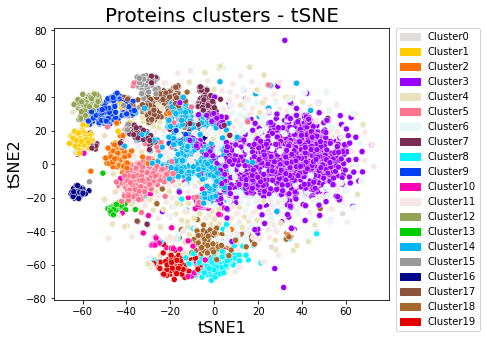

In [38]:
old = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/tsne_coordinates.csv', index_col=0)

plt.figure(figsize = (6,5))
plt.title("Proteins clusters - tSNE", fontsize=20)
plt.xlabel("tSNE1", fontsize=16)
plt.ylabel("tSNE2", fontsize=16)
fig = sns.scatterplot(x = old.iloc[:,0], y = old.iloc[:,1], hue=kmeans.labels_, palette = palette_20)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, handles=[clust0, clust1, clust2,
    clust3, clust4, clust5, clust6, clust7, clust8,clust9,clust10, clust11, clust12,clust13,clust14,
    clust15,clust16, clust17, clust18, clust19])


In [61]:
### UTILS ###

def get_top_de_prot(n):
    '''
    Get the entrez simbol for the top n proteins
    '''
    return top_bottom_DE[0:n]['EntrezGeneSymbol']



def find_id(names):
    ''' 
    Functin that searches for full 
    somamer ids given the provided name
    '''
    final_ids=[]
    for i in prot.columns:
        prot_name = i.split(".")[0]
        if prot_name in list(names):
            final_ids.append(i)
    return final_ids


def filter_df(data, idx):
    ''' 
    Filter data
    '''
    df = data.filter(items = idx, axis = 0)
    return df 


def tidyplot(filtered_data, label2, color):
    ''' 
    Make a pretty and tidy plot
    '''
    plt.figure(figsize = (6,5))
    plt.title("Proteins clusters - tSNE", fontsize=20)
    plt.xlabel("tSNE1", fontsize=16)
    plt.ylabel("tSNE2", fontsize=16)
    sns.scatterplot(x = old.iloc[:,0], y = old.iloc[:,1], label = 'Other proteins', color = 'darkgray', alpha = 0.7, s = 30)
    sns.scatterplot(x = filtered_data.iloc[:,0], y = filtered_data.iloc[:,1], label = label2, color = color, s = 30, alpha= 1.0)



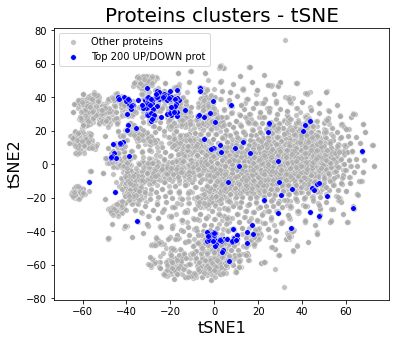

In [54]:
# import the dataset from the DE analysis between top bottom endotype (ISS>15)
top_bottom_DE = pd.read_csv('/Users/smasarone/Downloads/top over bottom.csv')

n_DE = 200
top_DE = get_top_de_prot(n_DE)
final_ids = find_id(top_DE)
tsne_top200 = filter_df(old, final_ids)
tidyplot(tsne_top200,label2 = 'Top 200 UP/DOWN prot', color = 'blue')

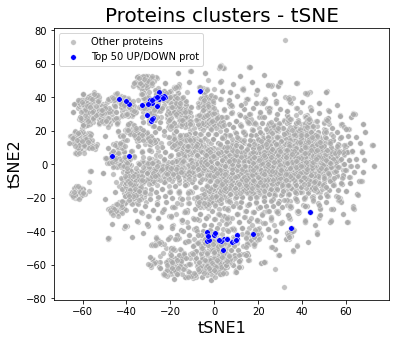

In [53]:
# top 50 DE proteins between A and B
n_DE = 50
top_50 = get_top_de_prot(n_DE)
final_ids = find_id(top_50)
tsne_top50 = filter_df(old, final_ids)
tidyplot(tsne_topde, label2 = 'Top 50 UP/DOWN prot', color = 'blue')

### Get enrichment results from DE A vs B >15

In [57]:
# plot enrichment 200 top de prot
EnrichR.plot_enrichment(top_DE, library_name = 'BioPlanet_2019', max_hits= 10, height = 300, width = 400)

alt.LayerChart(...)

In [60]:
# top 50
EnrichR.plot_enrichment(top_50, library_name = 'BioPlanet_2019', max_hits= 10, height = 300, width = 400)

alt.LayerChart(...)

### PLOT tSNE colored by expression

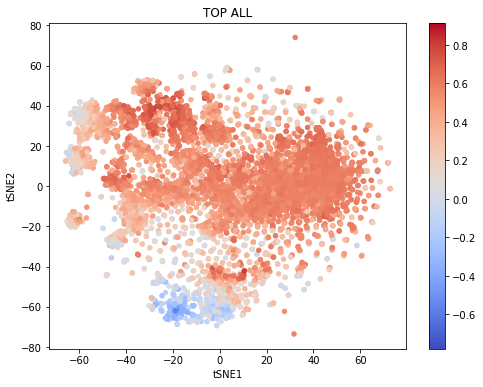

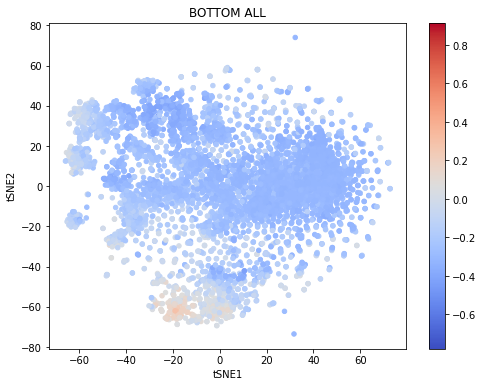

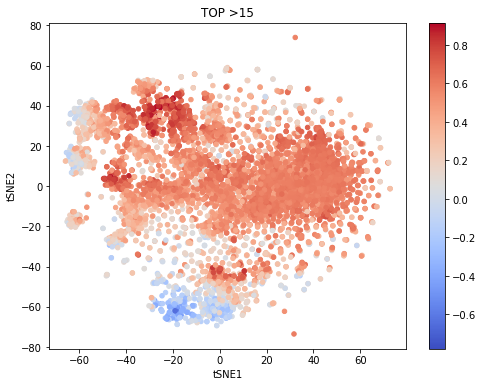

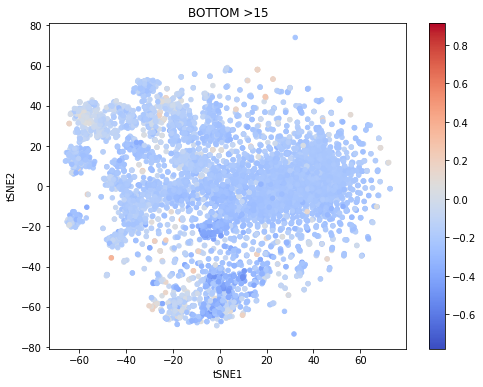

In [50]:
# read data
top = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/top_index.csv', index_col=0)
bottom = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/bottom_index.csv',index_col=0)
tops = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/tops_index.csv',index_col=0)
bottoms = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/bottoms_index.csv', index_col=0)

top_df = filter_df(df_scaled, top['TubeUniqueID'])
bottom_df = filter_df(df_scaled, bottom['TubeUniqueID'])
tops_df = filter_df(df_scaled, tops['TubeUniqueID'])
bottoms_df = filter_df(df_scaled, bottoms['TubeUniqueID'])
norm = plt.Normalize(-0.7784068222339884, 0.9161062168803082)  # always the same 



def plot_figure(differences, title):
    counter=0
    for diff, title in zip(differences, title):
        counter+=1
        plt.figure(figsize = (8,6))
        plt.title(title)
        fig = plt.scatter(x = old.iloc[:,0], y = old.iloc[:,1], c=diff, cmap='coolwarm', norm=norm, s = 20)
        plt.xlabel('tSNE1')
        plt.ylabel('tSNE2')
        scalarmappaple = cm.ScalarMappable(norm=norm, cmap='coolwarm')
        plt.colorbar(scalarmappaple)
        image_path = '/Users/smasarone/Downloads/TSNE_TOP_BOTTOM' + str(counter)+'.pdf'
        plt.savefig(image_path, format='pdf', dpi=1200, bbox_inches='tight')

a = np.mean(top_df, axis = 0)
b = np.mean(bottom_df, axis = 0)
c = np.mean(tops_df, axis = 0)
d = np.mean(bottoms_df, axis = 0)
plot_figure([a, b, c, d], ["ENDO ALL", "BOTTOM ALL", "TOP >15", "BOTTOM >15"])

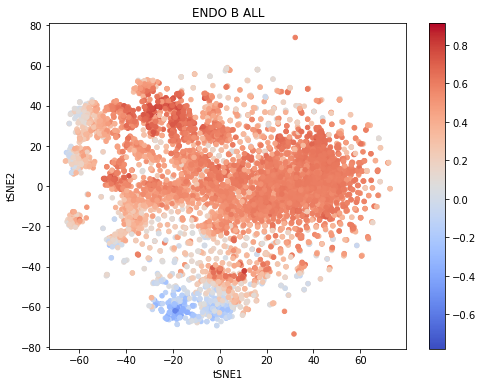

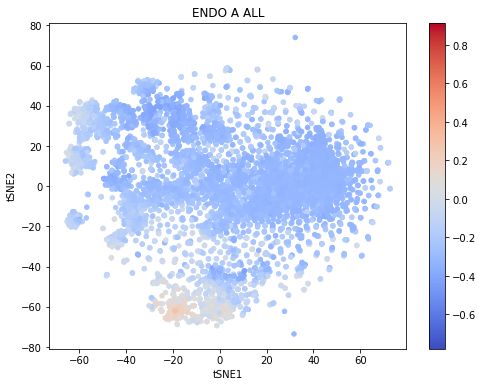

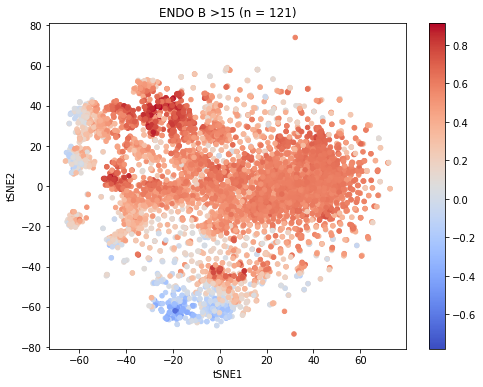

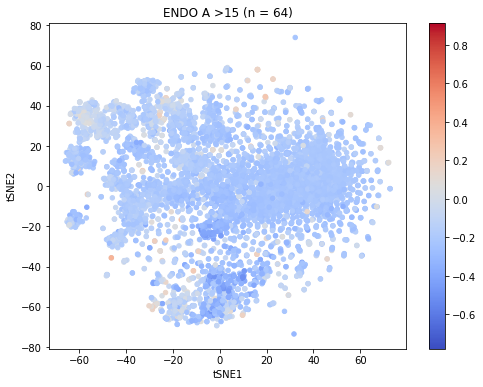

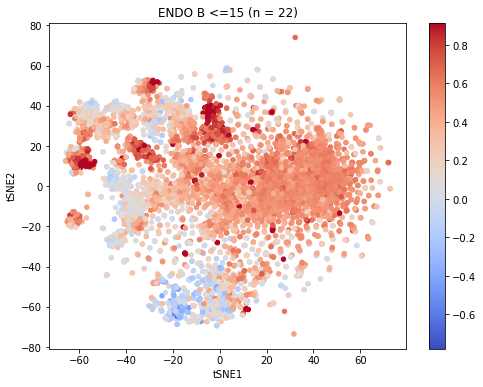

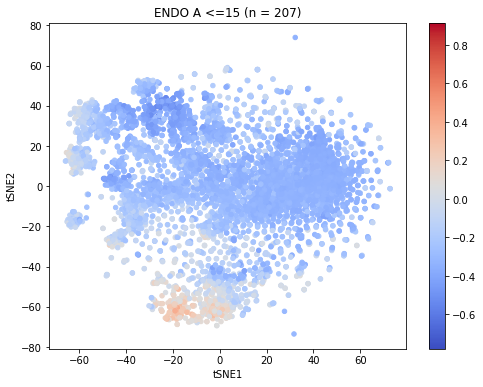

In [67]:
top.index = top['TubeUniqueID']
top['iss'] = clin['iss']
bottom.index = bottom['TubeUniqueID']
bottom['iss'] = clin['iss']
top_less15 = top[top['iss']<=15]
bottom_less15 = bottom[bottom['iss']<=15]

# filter the df for the ones that have iss <=15
tops_less15_df = filter_df(df_scaled, top_less15['TubeUniqueID'])
bottoms_less15_df = filter_df(df_scaled, bottom_less15['TubeUniqueID'])

e = np.mean(tops_less15_df, axis = 0)
f = np.mean(bottoms_less15_df, axis = 0)
plot_figure([a, b, c, d, e, f],["ENDO B ALL", 
                                "ENDO A ALL", 
                                "ENDO B >15 (n = 121)", 
                                "ENDO A >15 (n = 64)", 
                                "ENDO B <=15 (n = 22)", 
                                "ENDO A <=15 (n = 207)"])

In [87]:
import enrich_omics
from enrich_omics import EnrichR

# Read the data of DE between crit and controls and see where the points are on the map
DE = pd.read_csv("/Users/smasarone/allprot.csv", index_col=0)
top200 = DE.sort_values("logFC", ascending=False)[0:200].index
top_200 = [i.split(".")[0] for i in top200]

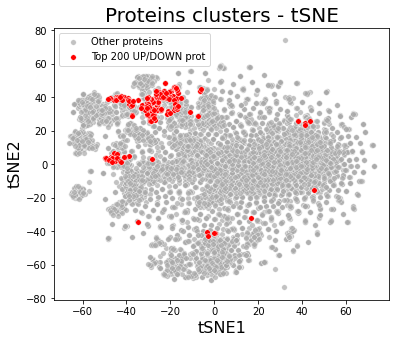

In [89]:
# predominnatly cluster 2, 7, 17 and 9 in controls vs critical.
tsne_top200 = filter_df(old, top200)
tidyplot(tsne_top200, label2 = 'Top 200 UP/DOWN prot', color = 'red')

In [ ]:
### mis-classified
one = df_scaled.loc[1131,:]
two = df_scaled.loc[1573,:]
three = df_scaled.loc[319,:]
four = df_scaled.loc[1442,:]

plot_figure([one, two, three, four], ['1131', '1573', '319', '1442'])
